Number of rows with likelihood > 0: 120


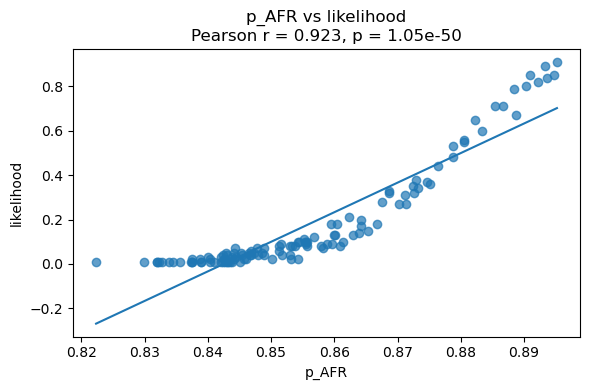

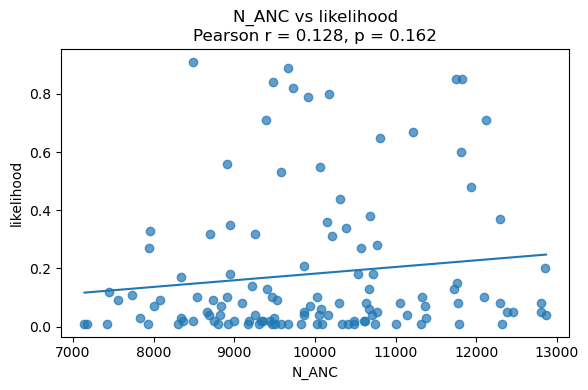

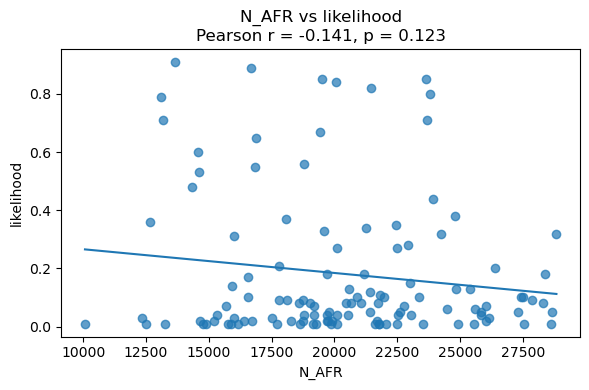

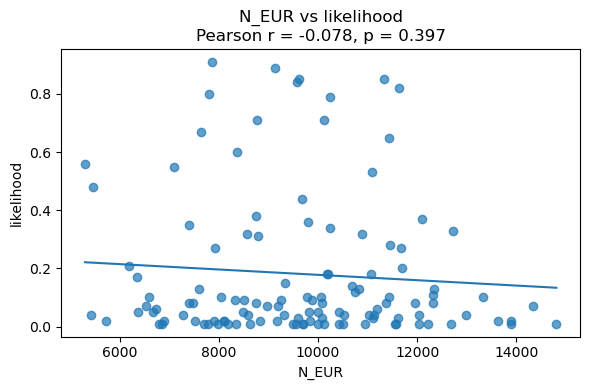

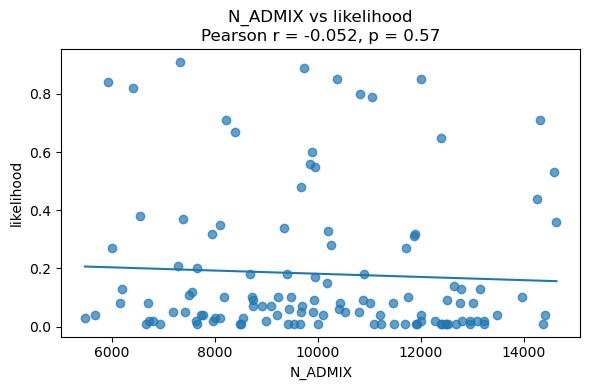

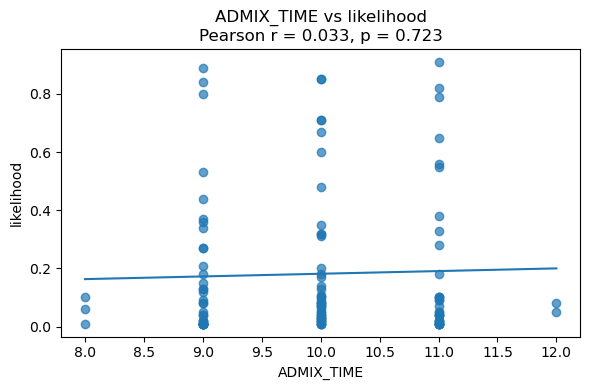

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm
df = pd.read_csv("../results/abc_simulation_500_normal.csv")

target_col = "likelihood"
cols_to_check = [
    "p_AFR",
    "N_ANC",
    "N_AFR",
    "N_EUR",
    "N_ADMIX",
    "ADMIX_TIME"
]

# =========================
# Filter rows
# =========================

df_pos = df[df[target_col] > 0].copy()

print(f"Number of rows with {target_col} > 0: {len(df_pos)}")

# =========================
# Correlation tests + linear regression
# =========================

results = []

for col in cols_to_check:
    x = df_pos[col]
    y = df_pos[target_col]

    tmp = pd.DataFrame({col: x, target_col: y}).dropna()
    x = tmp[col]
    y = tmp[target_col]

    pearson_r, pearson_p = pearsonr(x, y)

    spearman_r, spearman_p = spearmanr(x, y)

    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()

    slope = model.params[col]
    slope_p = model.pvalues[col]
    r_squared = model.rsquared

    results.append({
        "variable": col,
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "spearman_r": spearman_r,
        "spearman_p": spearman_p,
        "linear_slope": slope,
        "linear_slope_p": slope_p,
        "r_squared": r_squared
    })

results_df = pd.DataFrame(results)

for col in cols_to_check:
    tmp = df_pos[[col, target_col]].dropna()
    x = tmp[col]
    y = tmp[target_col]

    pearson_r, pearson_p = pearsonr(x, y)

    slope, intercept = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept

    plt.figure(figsize=(6, 4))
    plt.scatter(x, y, alpha=0.7)
    plt.plot(x_line, y_line)
    plt.xlabel(col)
    plt.ylabel(target_col)
    plt.title(
        f"{col} vs {target_col}\n"
        f"Pearson r = {pearson_r:.3f}, p = {pearson_p:.3g}"
    )

    plt.tight_layout()
    plt.show()

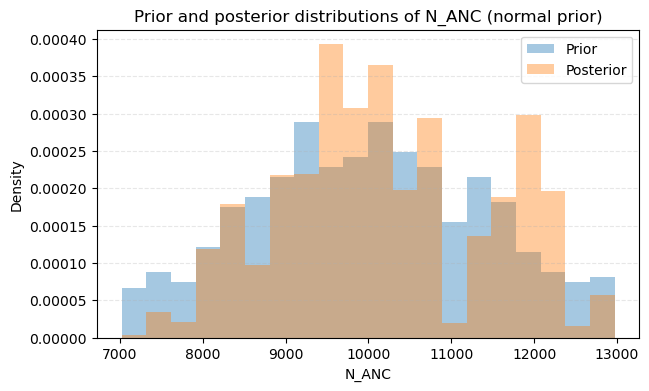

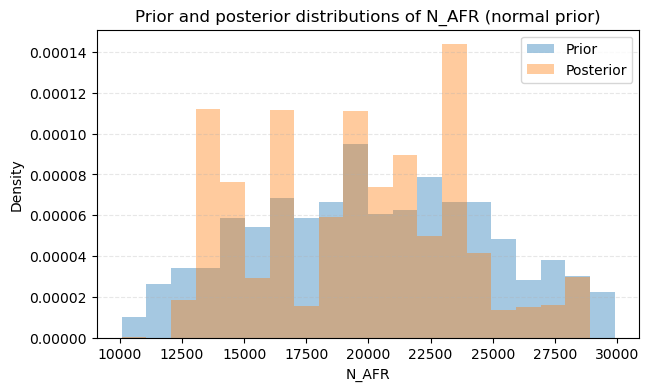

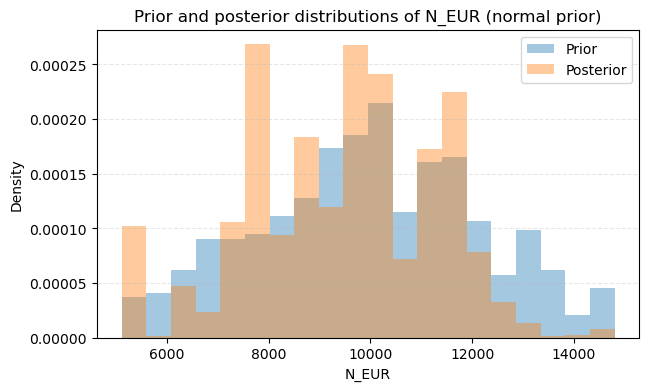

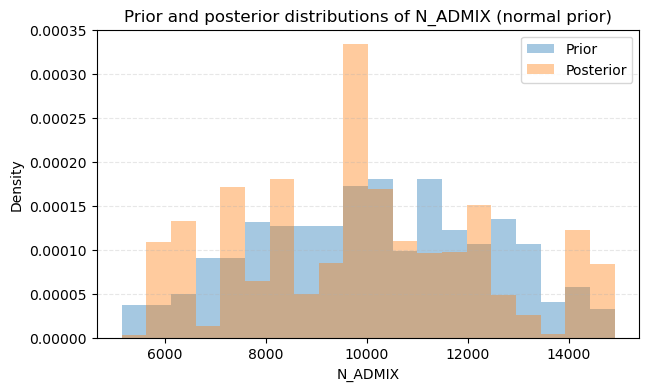

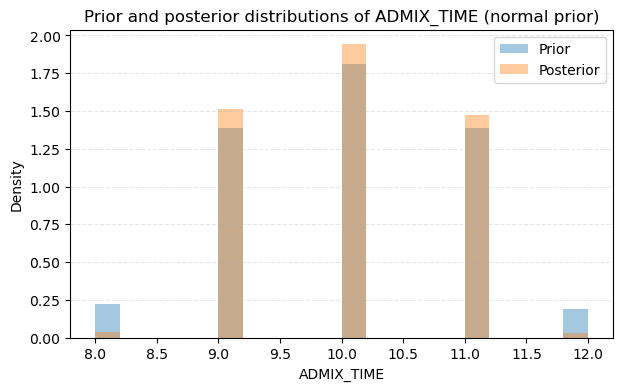

In [16]:
parameters = [
    "N_ANC",
    "N_AFR",
    "N_EUR",
    "N_ADMIX",
    "ADMIX_TIME",
]

for parameter in parameters:

    bins = 20

    plt.figure(figsize=(7, 4))

    plt.hist(
        df[parameter],
        bins=bins,
        density=True,
        alpha=0.4,
        label="Prior"
    )

    plt.hist(
        df[parameter],
        bins=bins,
        weights=df["posterior"],
        density=True,
        alpha=0.4,
        label="Posterior"
    )

    plt.xlabel(parameter)
    plt.ylabel("Density")
    plt.title(
        f"Prior and posterior distributions of {parameter} "
        f"(normal prior)"
    )

    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.3)
    plt.show()